<a href="https://www.kaggle.com/code/ashikuzzamanshishir/test-module?scriptVersionId=282455997" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

#  Bone Fracture Detection

This notebook presents detecting bone fractures from X-ray images.  
It covers CNN backbones, attention modules, transformer architectures, cross-validation, and Grad-CAM visualization .


##  1. Environment Setup
Import dependencies, define dataset paths, and configure GPU/CPU usage.  
Prepare all required folders and initialize the workspace.


In [1]:


import os, sys, shutil, random, glob, time, json, gc, math
from collections import defaultdict
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cv2
from tqdm import tqdm

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim
from statsmodels.stats.contingency_tables import mcnemar

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, CSVLogger


try:
    import torch, timm
    from torch import nn
    from torch.utils.data import Dataset, DataLoader
    from torchvision import transforms
    TORCH_OK = True
except Exception:
    TORCH_OK = False

print("TensorFlow:", tf.__version__)
print("PyTorch ok:", TORCH_OK)


2025-11-28 15:34:04.582421: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764344044.802109      38 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764344044.858765      38 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2225: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `ty

TensorFlow: 2.18.0
PyTorch ok: True


## 2. Data Preparation
Load the bone fracture dataset, verify class distribution, and split into **train**, **validation**, and **test** sets.  
Applies consistent directory-based structure for compatibility with Keras and PyTorch.

In [2]:

DATA_DIR = "/kaggle/input/bone-fracture-dataset/Bone fracture dataset/Dataset"
WORK_DIR = "/kaggle/working/bone_fracture_work"
SPLIT_ROOT = os.path.join(WORK_DIR, "splits")
TRAIN_DIR = os.path.join(SPLIT_ROOT, "train")
VAL_DIR   = os.path.join(SPLIT_ROOT, "val")
TEST_DIR  = os.path.join(SPLIT_ROOT, "test")
AUG_TRAIN_DIR = os.path.join(SPLIT_ROOT, "train_aug2")
MIXT_DIR  = os.path.join(SPLIT_ROOT, "mixt")

os.makedirs(WORK_DIR, exist_ok=True)


IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 10              
VAL_SPLIT = 0.15
TEST_SPLIT = 0.15
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)


MIXT_TOTAL = 20
MIXT_PER_CLASS = MIXT_TOTAL // 2


FAST_MODE = True   


FULL_EPOCHS = 40
RUN_CNN_MODELS = not FAST_MODE
RUN_ATTENTION  = not FAST_MODE
RUN_TRANSFORMERS = (not FAST_MODE) and TORCH_OK
RUN_ENSEMBLE  = not FAST_MODE
RUN_FIVE_FOLD = not FAST_MODE
RUN_OPTUNA    = False  # Optional; off by default

print("FAST_MODE:", FAST_MODE)
print("WORK_DIR:", WORK_DIR)


FAST_MODE: True
WORK_DIR: /kaggle/working/bone_fracture_work


## 3.  Dataset Structure & Image Counting

 This helps verify that the dataset is loaded correctly before any preprocessing or model training begins.


In [3]:
IMG_EXT = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")
classes = [d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))]
classes = sorted(classes)
assert len(classes) == 2, f"Expected 2 classes; found {classes}"
print("Detected classes:", classes)

all_paths = {c: sorted([p for p in glob.glob(os.path.join(DATA_DIR, c, "**"), recursive=True)
                        if os.path.isfile(p) and p.lower().endswith(IMG_EXT)])
             for c in classes}
counts = {c: len(all_paths[c]) for c in classes}
print("Image counts:", counts, "| Total:", sum(counts.values()))


Detected classes: ['fracture', 'normal']
Image counts: {'fracture': 2000, 'normal': 127} | Total: 2127


## 4.  Dataset Splitting — Train, Validation & Test Sets

This cell automatically splits the dataset into:
- **Training set** → used to train the model  
- **Validation set** → used to tune model hyperparameters  
- **Test set** → used to evaluate final performance  



This ensures a clean, reproducible train/validation/test structure before model training begins.


In [4]:
if os.path.exists(SPLIT_ROOT):
    shutil.rmtree(SPLIT_ROOT)

for root in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    for c in classes:
        os.makedirs(os.path.join(root, c), exist_ok=True)

for c in classes:
    paths = all_paths[c]
    temp, test_c = train_test_split(paths, test_size=TEST_SPLIT, random_state=SEED, shuffle=True)
    rel_val = VAL_SPLIT / (1.0 - TEST_SPLIT)
    train_c, val_c = train_test_split(temp, test_size=rel_val, random_state=SEED, shuffle=True)
    for src in train_c:
        shutil.copy2(src, os.path.join(TRAIN_DIR, c, os.path.basename(src)))
    for src in val_c:
        shutil.copy2(src, os.path.join(VAL_DIR, c, os.path.basename(src)))
    for src in test_c:
        shutil.copy2(src, os.path.join(TEST_DIR, c, os.path.basename(src)))

def count_dir(root):
    return {c: len(glob.glob(os.path.join(root, c, "*"))) for c in classes}

print("Split counts:")
print("Train:", count_dir(TRAIN_DIR))
print("Val  :", count_dir(VAL_DIR))
print("Test :", count_dir(TEST_DIR))


Split counts:
Train: {'fracture': 1400, 'normal': 88}
Val  : {'fracture': 300, 'normal': 19}
Test : {'fracture': 300, 'normal': 20}


## 5. Image Preprocessing — CLAHE Enhancement & Normalization

In [5]:
def preprocess_image_np(img_rgb_uint8):
    lab = cv2.cvtColor(img_rgb_uint8, cv2.COLOR_RGB2LAB)
    L, A, B = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    L2 = clahe.apply(L)
    lab2 = cv2.merge([L2, A, B])
    rgb2 = cv2.cvtColor(lab2, cv2.COLOR_LAB2RGB)
    rgb2 = cv2.GaussianBlur(rgb2, (3,3), 0)   # optional denoise
    rgb2 = rgb2.astype(np.float32) / 255.0
    return rgb2

def preprocessing_function(img):
    img = np.clip(img, 0, 255).astype(np.uint8)
    return preprocess_image_np(img)

def load_resize_rgb(path, size=IMG_SIZE):
    x = cv2.imread(path, cv2.IMREAD_COLOR)
    x = cv2.cvtColor(x, cv2.COLOR_BGR2RGB)
    x = cv2.resize(x, size, interpolation=cv2.INTER_AREA)
    return x


## 6. Image Quality Evaluation — PSNR & SSIM Metrics

This cell quantitatively measures the **improvement in image quality** after preprocessing.

In [6]:
sample_files = []
for c in classes:
    pool = glob.glob(os.path.join(TRAIN_DIR, c, "*"))
    sample_files += random.sample(pool, min(8, len(pool)))

psnr_vals, ssim_vals = [], []
for p in sample_files:
    raw = load_resize_rgb(p)
    proc = (preprocess_image_np(raw) * 255.0).astype(np.uint8)
    psnr_vals.append(psnr(raw, proc, data_range=255))
    ssim_vals.append(ssim(raw, proc, channel_axis=2, data_range=255))

print(f"Sample size: {len(sample_files)} | Avg PSNR: {np.mean(psnr_vals):.3f} dB | Avg SSIM: {np.mean(ssim_vals):.4f}")


Sample size: 16 | Avg PSNR: 25.427 dB | Avg SSIM: 0.9142


## 7. Data Augmentation — Expanding the Training Dataset

This cell generates **augmented versions** of all training images to increase dataset diversity and improve model generalization.

In [7]:
if os.path.exists(AUG_TRAIN_DIR):
    shutil.rmtree(AUG_TRAIN_DIR)
for c in classes:
    os.makedirs(os.path.join(AUG_TRAIN_DIR, c), exist_ok=True)

aug_gen_1 = ImageDataGenerator(
    preprocessing_function=preprocessing_function,
    rotation_range=12, width_shift_range=0.08, height_shift_range=0.08,
    zoom_range=0.12, horizontal_flip=True, fill_mode="nearest"
)
aug_gen_2 = ImageDataGenerator(
    preprocessing_function=preprocessing_function,
    rotation_range=8, width_shift_range=0.06, height_shift_range=0.06,
    zoom_range=0.10, horizontal_flip=True, shear_range=6, fill_mode="nearest"
)

def save_aug_versions(input_dir, out_dir, versions=2):
    for c in classes:
        cur = glob.glob(os.path.join(input_dir, c, "*"))
        for src in tqdm(cur, desc=f"Aug {c}"):
            base = os.path.splitext(os.path.basename(src))[0]
            img = load_resize_rgb(src, IMG_SIZE)
            for k in range(versions):
                gen = aug_gen_1 if k == 0 else aug_gen_2
                x = tf.keras.preprocessing.image.img_to_array(img).astype(np.float32)
                x = np.expand_dims(x, 0)
                aug_iter = gen.flow(x, batch_size=1, shuffle=False)
                aug = next(aug_iter)[0]     # already preprocessed to [0,1]
                out = (aug * 255).astype(np.uint8)
                out_path = os.path.join(out_dir, c, f"{base}_aug{k+1}.jpg")
                cv2.imwrite(out_path, cv2.cvtColor(out, cv2.COLOR_RGB2BGR))

save_aug_versions(TRAIN_DIR, AUG_TRAIN_DIR, versions=2)
print("Aug counts:", count_dir(AUG_TRAIN_DIR))


Aug normal: 100%|██████████| 88/88 [00:07<00:00, 12.12it/s]

Aug counts: {'fracture': 2800, 'normal': 176}


## 8. Data Generators — Preparing Data Pipelines for Training, Validation & Testing

In [8]:
train_gen = ImageDataGenerator(preprocessing_function=preprocessing_function)
val_test_gen = ImageDataGenerator(preprocessing_function=preprocessing_function)

train_flow = train_gen.flow_from_directory(AUG_TRAIN_DIR, target_size=IMG_SIZE,
                                           batch_size=BATCH_SIZE, class_mode="binary", shuffle=True, seed=SEED)
val_flow = val_test_gen.flow_from_directory(VAL_DIR, target_size=IMG_SIZE,
                                           batch_size=BATCH_SIZE, class_mode="binary", shuffle=False)
test_flow = val_test_gen.flow_from_directory(TEST_DIR, target_size=IMG_SIZE,
                                            batch_size=BATCH_SIZE, class_mode="binary", shuffle=False)

idx_to_class = {v:k for k,v in train_flow.class_indices.items()}
classes_ordered = [k for k,_ in sorted(train_flow.class_indices.items(), key=lambda x:x[1])]
print("Class indices:", train_flow.class_indices)


Found 2976 images belonging to 2 classes.
Found 319 images belonging to 2 classes.
Found 320 images belonging to 2 classes.
Class indices: {'fracture': 0, 'normal': 1}


## 9. Evaluation Utilities — Metrics, Bootstrap Confidence, and Timer


In [9]:
def binary_metrics(y_true, y_pred, y_prob=None):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    acc = (tp+tn)/cm.sum()
    ppv = tp/(tp+fp+1e-9)         
    npv = tn/(tn+fn+1e-9)
    sens = tp/(tp+fn+1e-9)        
    spec = tn/(tn+fp+1e-9)
    f1 = 2*ppv*sens/(ppv+sens+1e-9)
    return {"accuracy":acc, "precision":ppv, "recall":sens, "specificity":spec, "npv":npv, "f1":f1, "cm":cm}

def bootstrap_accuracy(y_true, y_pred, n=1000, seed=SEED):
    rng = np.random.default_rng(seed)
    idx = np.arange(len(y_true))
    accs = [accuracy_score(y_true[rng.choice(idx, size=len(idx), replace=True)],
                           y_pred[rng.choice(idx, size=len(idx), replace=True)]) for _ in range(n)]
    lo, hi = np.percentile(accs, [2.5, 97.5])
    return {"mean": float(np.mean(accs)), "ci95": (float(lo), float(hi))}

class Timer:
    def __enter__(self): self.t0=time.time(); return self
    def __exit__(self,*exc): self.elapsed=time.time()-self.t0


## 10. Model Building & Training — EfficientNetB0 Baseline

#### - Model Architecture
### - Configuration
### - Callbacks

In [10]:
from tensorflow.keras.applications import EfficientNetB0

L2 = 1e-4
DROP = 0.5

def build_efficientnet():
    base = EfficientNetB0(include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3), weights="imagenet")
    base.trainable = False
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dropout(DROP)(x)
    out = layers.Dense(1, activation="sigmoid", kernel_regularizer=regularizers.l2(L2))(x)
    m = models.Model(base.input, out, name="EfficientNetB0_bin")
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="binary_crossentropy", metrics=["accuracy"])
    return m, base

E = FULL_EPOCHS if not FAST_MODE else EPOCHS
m, base = build_efficientnet()
callbacks = [
    EarlyStopping(monitor="val_accuracy", patience=5 if not FAST_MODE else 3, restore_best_weights=True, verbose=1),
    ModelCheckpoint(os.path.join(WORK_DIR,"best_effb0.h5"), monitor="val_accuracy", save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1),
]
with Timer() as ttrain:
    hist = m.fit(train_flow, validation_data=val_flow, epochs=E, verbose=1)

print(f"Train time (s): {ttrain.elapsed:.1f}")


I0000 00:00:1764344126.974497      38 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1764344145.627485     131 service.cc:148] XLA service 0x7905a004cd30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1764344145.628227     131 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1764344147.425707     131 cuda_dnn.cc:529] Loaded cuDNN version 90300


  4/186 ━━━━━━━━━━━━━━━━━━━━ 8s 47ms/step - accuracy: 0.4219 - loss: 0.7193   

I0000 00:00:1764344155.711780     131 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


186/186 ━━━━━━━━━━━━━━━━━━━━ 49s 133ms/step - accuracy: 0.8997 - loss: 0.2999 - val_accuracy: 0.9404 - val_loss: 0.2266
Epoch 2/10
186/186 ━━━━━━━━━━━━━━━━━━━━ 14s 74ms/step - accuracy: 0.9377 - loss: 0.2369 - val_accuracy: 0.9404 - val_loss: 0.2307
Epoch 3/10
186/186 ━━━━━━━━━━━━━━━━━━━━ 14s 73ms/step - accuracy: 0.9420 - loss: 0.2265 - val_accuracy: 0.9404 - val_loss: 0.2312
Epoch 4/10
186/186 ━━━━━━━━━━━━━━━━━━━━ 14s 73ms/step - accuracy: 0.9403 - loss: 0.2344 - val_accuracy: 0.9404 - val_loss: 0.2270
Epoch 5/10
186/186 ━━━━━━━━━━━━━━━━━━━━ 14s 73ms/step - accuracy: 0.9359 - loss: 0.2454 - val_accuracy: 0.9404 - val_loss: 0.2262
Epoch 6/10
186/186 ━━━━━━━━━━━━━━━━━━━━ 14s 72ms/step - accuracy: 0.9407 - loss: 0.2301 - val_accuracy: 0.9404 - val_loss: 0.2270
Epoch 7/10
186/186 ━━━━━━━━━━━━━━━━━━━━ 14s 73ms/step - accuracy: 0.9442 - loss: 0.2221 - val_accuracy: 0.9404 - val_loss: 0.2270
Epoch 8/10
186/186 ━━━━━━━━━━━━━━━━━━━━ 13s 72ms/step - accuracy: 0.9387 - loss: 0.2342 - val_accura

## 11. Model Evaluation & Confusion Matrices (Train / Validation / Test)

This cell evaluates the **EfficientNetB0 model** across all dataset splits — training, validation, and test — and visualizes classification results using **confusion matrices**.


####  Split Evaluations
Runs evaluation on:
- **Train set**  
- **Validation set**   
- **Test set** 

####  Confusion Matrices
For each split, a confusion matrix is plotted to visualize


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classif

== Train ==
              precision    recall  f1-score   support

    fracture       0.94      1.00      0.97      2800
      normal       0.00      0.00      0.00       176

    accuracy                           0.94      2976
   macro avg       0.47      0.50      0.48      2976
weighted avg       0.89      0.94      0.91      2976

== Val ==
              precision    recall  f1-score   support

    fracture       0.94      1.00      0.97       300
      normal       0.00      0.00      0.00        19

    accuracy                           0.94       319
   macro avg       0.47      0.50      0.48       319
weighted avg       0.88      0.94      0.91       319

== Test ==
              precision    recall  f1-score   support

    fracture       0.94      1.00      0.97       300
      normal       0.00      0.00      0.00        20

    accuracy                           0.94       320
   macro avg       0.47      0.50      0.48       320
weighted avg       0.88      0.94      0.

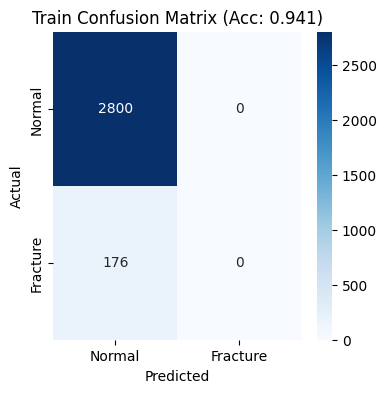

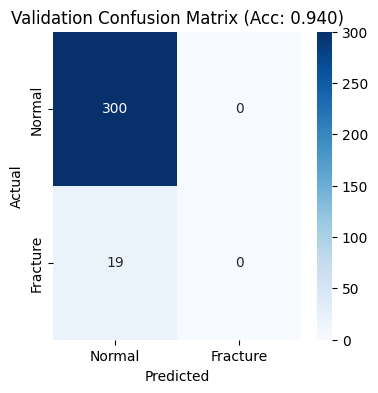

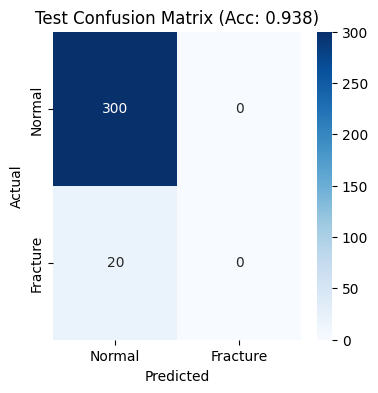

In [11]:

#  Evaluation with Confusion Matrices (Train / Val / Test)

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def eval_gen(model, gen):
    """Evaluate model on a generator and compute metrics."""
    loss, acc = model.evaluate(gen, verbose=0)
    prob = model.predict(gen, verbose=0).ravel()
    pred = (prob >= 0.5).astype(int)
    y = gen.classes
    met = binary_metrics(y, pred, prob)
    rep = classification_report(y, pred, target_names=classes_ordered)
    boot = bootstrap_accuracy(y, pred, 1000 if not FAST_MODE else 200)
    return {"loss":loss,"acc":acc,"metrics":met,"report":rep,"boot_acc":boot, "y":y, "pred":pred}


train_eval = eval_gen(m, train_flow)
val_eval   = eval_gen(m, val_flow)
test_eval  = eval_gen(m, test_flow)

# Print reports
print("== Train ==")
print(train_eval["report"])
print("== Val ==")
print(val_eval["report"])
print("== Test ==")
print(test_eval["report"])
print("Bootstrap Acc (test):", test_eval["boot_acc"])


splits = {
    "Train": train_eval,
    "Validation": val_eval,
    "Test": test_eval
}

for name, result in splits.items():
    y_true = result["y"]
    y_pred = result["pred"]
    cm = confusion_matrix(y_true, y_pred)
    acc = result["acc"]
    
    plt.figure(figsize=(4,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Normal", "Fracture"],
                yticklabels=["Normal", "Fracture"])
    plt.title(f"{name} Confusion Matrix (Acc: {acc:.3f})")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


## 12. Training Progress Visualization — Accuracy & Loss Curves

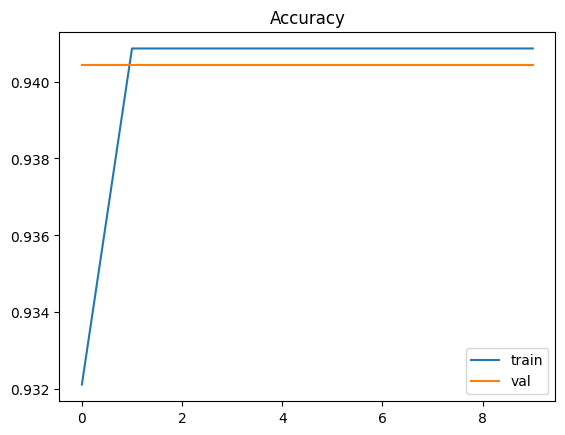

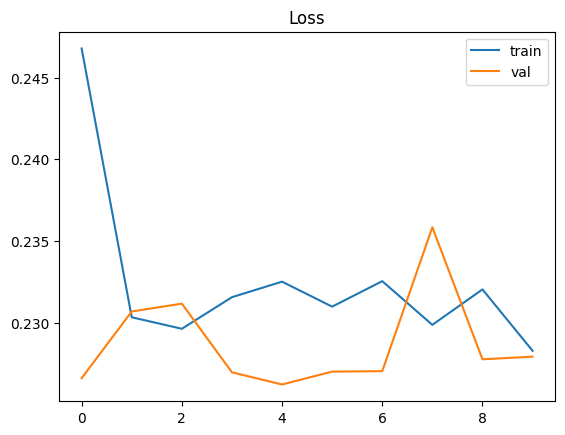

In [12]:
plt.figure(); plt.plot(hist.history["accuracy"], label="train"); plt.plot(hist.history.get("val_accuracy",[]), label="val")
plt.title("Accuracy"); plt.legend(); plt.show()
plt.figure(); plt.plot(hist.history["loss"], label="train"); plt.plot(hist.history.get("val_loss",[]), label="val")
plt.title("Loss"); plt.legend(); plt.show()


## 13. Grad-CAM 

### Outputs
   For each random image:
   -  Original X-ray  
   -  Grad-CAM Heatmap (model attention)  
   -  Overlay with predicted **fracture probability**

 Using main dataset folder: /kaggle/input/bone-fracture-dataset/Bone fracture dataset/Dataset
 Found 2127 total images (fracture + normal)
Using device: /GPU:0
Running Grad-CAM on 5 random images from main dataset...

🩻 [1] 673.png


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


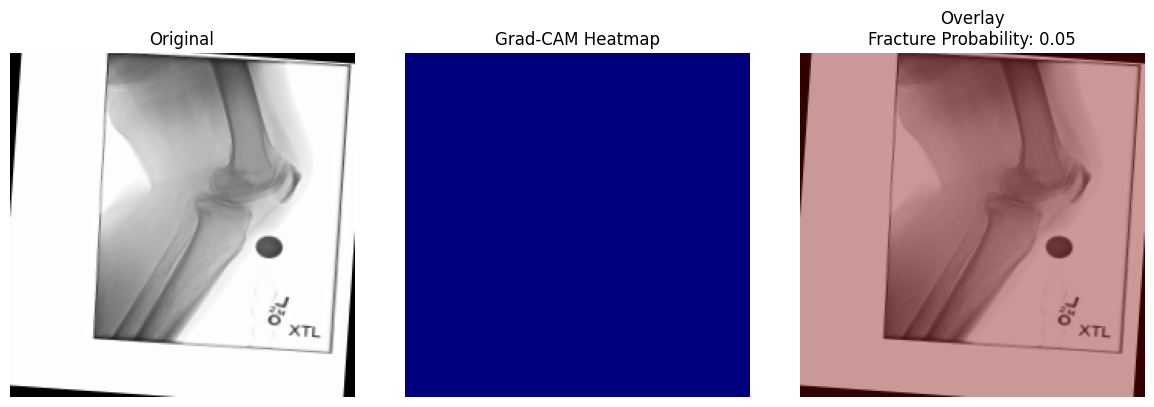


🩻 [2] 1839.png


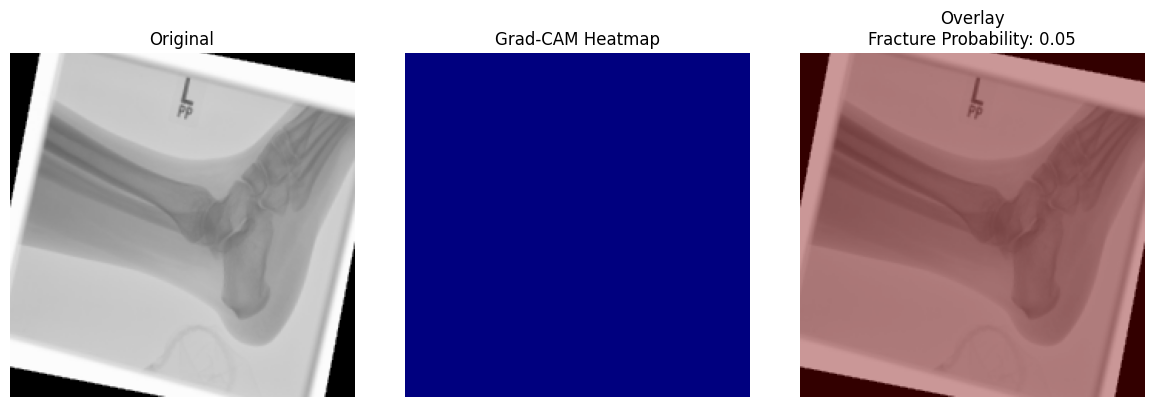


🩻 [3] 112.png


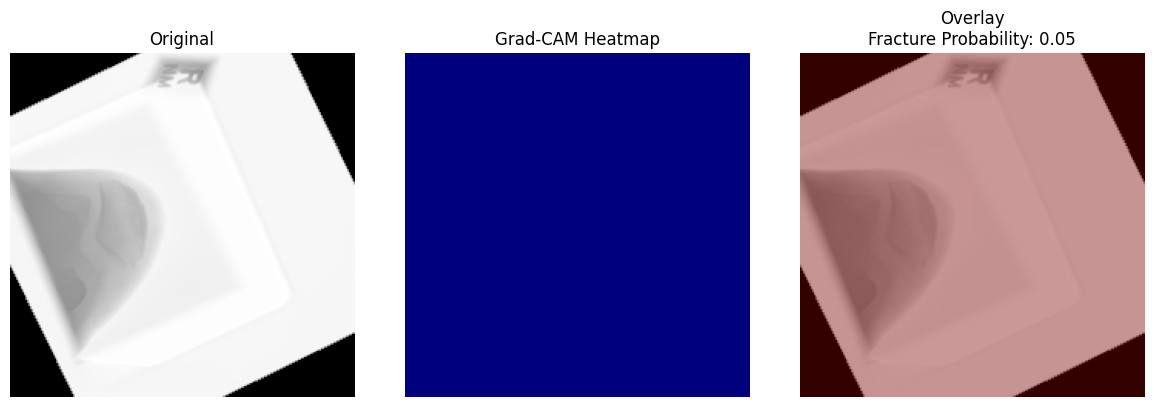


🩻 [4] 1334.png


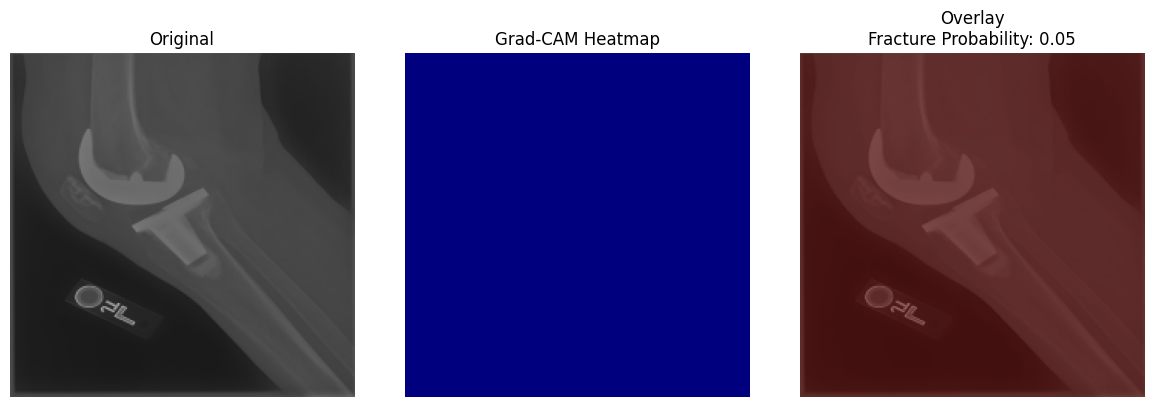


🩻 [5] 671.png


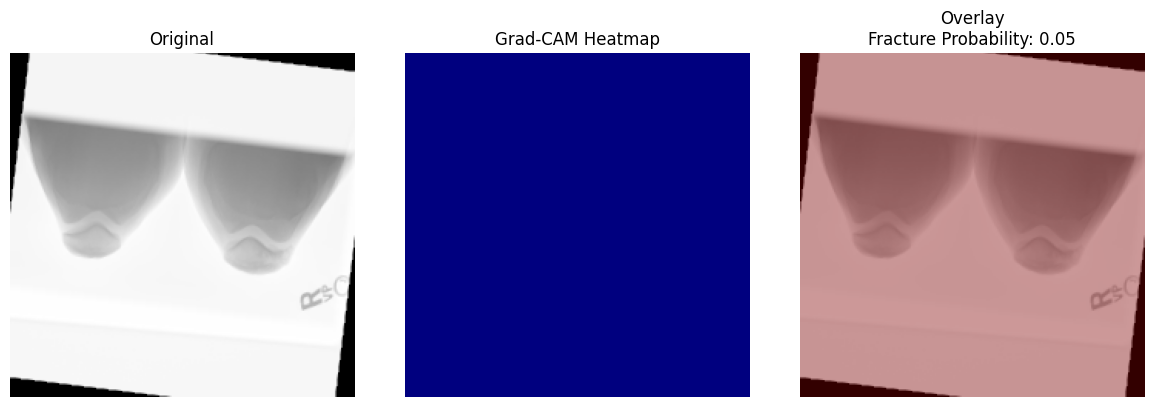

In [13]:
# ==========================================================
#  Grad-CAM Visualization 
# ==========================================================
import os, glob, random, cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt


root_candidates = [
    "/kaggle/input/bone-fracture-dataset/",
    "/kaggle/input/bone-fracture-dataset-only/",
    "/kaggle/input/"
]

SOURCE_MAIN = None
for root in root_candidates:
    for subdir, dirs, files in os.walk(root):
        if "fracture" in dirs and "normal" in dirs:
            SOURCE_MAIN = subdir
            break
    if SOURCE_MAIN:
        break

if not SOURCE_MAIN:
    raise FileNotFoundError(" Could not locate main dataset folder containing 'fracture' and 'normal'!")

print(f" Using main dataset folder: {SOURCE_MAIN}")


all_imgs = glob.glob(os.path.join(SOURCE_MAIN, "fracture", "*.*")) + \
           glob.glob(os.path.join(SOURCE_MAIN, "normal", "*.*"))
all_imgs = [f for f in all_imgs if f.lower().endswith(("jpg", "jpeg", "png"))]

if not all_imgs:
    raise RuntimeError(" No images found inside main dataset folder!")

print(f" Found {len(all_imgs)} total images (fracture + normal)")


if "m" in globals():
    model_to_use = m
elif "models_list" in globals() and len(models_list) > 0:
    model_to_use = models_list[0]
else:
    raise RuntimeError("No trained model found! Please train or load a model first.")

device_name = "/GPU:0" if tf.config.list_physical_devices('GPU') else "/CPU:0"
print(f"Using device: {device_name}")


def load_rgb(img_path, size=(224, 224)):
    img = cv2.imread(img_path)
    if img is None:
        raise FileNotFoundError(f" Cannot read: {img_path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, size)
    return img

def grad_cam(model, img_path, size=(224, 224)):
    raw = load_rgb(img_path, size)
    x = np.expand_dims(raw.astype(np.float32) / 255.0, axis=0)

    # Find last conv layer
    last_conv = None
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            last_conv = layer.name
            break
    if last_conv is None:
        raise ValueError(" No Conv2D layer found in model.")

    grad_model = tf.keras.models.Model([model.inputs],
                                       [model.get_layer(last_conv).output, model.output])

    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(x)
        class_channel = preds[:, 0]

    grads = tape.gradient(class_channel, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2)).numpy()
    conv_output = conv_out[0].numpy()

    for i in range(pooled_grads.shape[-1]):
        conv_output[:, :, i] *= pooled_grads[i]

    heatmap = np.mean(conv_output, axis=-1)
    heatmap = np.maximum(heatmap, 0)
    heatmap /= (np.max(heatmap) + 1e-8)
    heatmap = cv2.resize(heatmap, (raw.shape[1], raw.shape[0]))
    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(raw, 0.6, heatmap_color, 0.4, 0)

    return raw, heatmap, overlay, float(preds.numpy()[0][0])


num_samples = 5
chosen_imgs = random.sample(all_imgs, min(num_samples, len(all_imgs)))
print(f"Running Grad-CAM on {len(chosen_imgs)} random images from main dataset...")

for i, img_path in enumerate(chosen_imgs, 1):
    print(f"\n🩻 [{i}] {os.path.basename(img_path)}")
    raw, hm, ov, prob = grad_cam(model_to_use, img_path)

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1); plt.imshow(raw); plt.title("Original"); plt.axis("off")
    plt.subplot(1, 3, 2); plt.imshow(hm, cmap="jet"); plt.title("Grad-CAM Heatmap"); plt.axis("off")
    plt.subplot(1, 3, 3); plt.imshow(ov); plt.title(f"Overlay\nFracture Probability: {prob:.2f}"); plt.axis("off")
    plt.tight_layout()
    plt.show()


## 14 CNN Backbone Training & Evaluation

###  Purpose
To identify which CNN backbone performs best for the given dataset by comparing accuracy, F1-score, precision, recall, and specificity.

### CNN Architectures Used
- **ResNet50**  
- **VGG16**   
- **InceptionV3** 
- **Xception** 
- **DenseNet121**
- **MobileNetV2** 
- **EfficientNetB0**
- **NASNetMobile**



Using GPU for training: /physical_device:GPU:0
 Starting CNN training & evaluation for all backbones...

==================== ResNet50 ====================
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step

Training ResNet50 for 5 epochs...
Epoch 1/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.9049 - loss: 0.3031
Epoch 1: val_accuracy improved from -inf to 0.94044, saving model to /kaggle/working/bone_fracture_work/ResNet50_best.h5
186/186 ━━━━━━━━━━━━━━━━━━━━ 34s 114ms/step - accuracy: 0.9051 - loss: 0.3028 - val_accuracy: 0.9404 - val_loss: 0.2270 - learning_rate: 0.0010
Epoch 2/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.9424 - loss: 0.2252
Epoch 2: val_accuracy did not improve from 0.94044
186/186 ━━━━━━━━━━━━━━━━━━━━ 14s 73ms/step - accuracy: 0.9424 - loss: 0.2253 - val_accuracy: 0.9404 - val_loss: 0.2301 - learning_rate: 0.0010
Epoch 3/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.9379 - loss: 0.2408
Epoch 3: val_accuracy did not improve fro

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


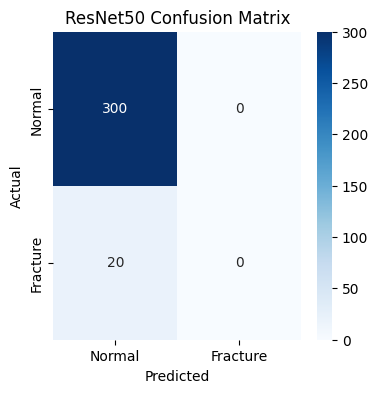

==================== VGG16 ====================
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step

Training VGG16 for 5 epochs...
Epoch 1/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.8835 - loss: 0.3503
Epoch 1: val_accuracy improved from -inf to 0.94044, saving model to /kaggle/working/bone_fracture_work/VGG16_best.h5
186/186 ━━━━━━━━━━━━━━━━━━━━ 25s 100ms/step - accuracy: 0.8837 - loss: 0.3499 - val_accuracy: 0.9404 - val_loss: 0.2191 - learning_rate: 0.0010
Epoch 2/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9381 - loss: 0.2314
Epoch 2: val_accuracy did not improve from 0.94044
186/186 ━━━━━━━━━━━━━━━━━━━━ 14s 77ms/step - accuracy: 0.9381 - loss: 0.2314 - val_accuracy: 0.9404 - val_loss: 0.2173 - learning_rate: 0.0010
Epoch 3/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.9459 - loss: 0.2028
Epoch 3: val_accuracy did not improve from 0.94044
186/186 ━━━━━━━━━━━━━━━━━━━━ 14s 75ms/step - accuracy: 0.9458 - loss: 0.2029 - val_accuracy: 0.9404 - va

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


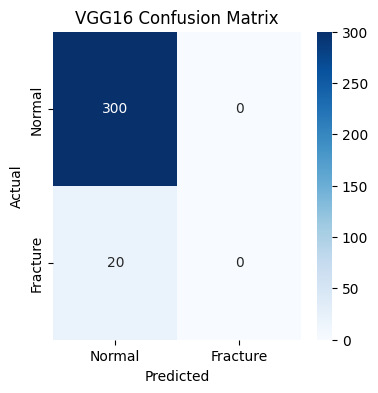

==================== InceptionV3 ====================
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step

Training InceptionV3 for 5 epochs...
Epoch 1/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.9189 - loss: 0.2964
Epoch 1: val_accuracy improved from -inf to 0.94044, saving model to /kaggle/working/bone_fracture_work/InceptionV3_best.h5
186/186 ━━━━━━━━━━━━━━━━━━━━ 42s 139ms/step - accuracy: 0.9190 - loss: 0.2961 - val_accuracy: 0.9404 - val_loss: 0.2166 - learning_rate: 0.0010
Epoch 2/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.9382 - loss: 0.1717
Epoch 2: val_accuracy improved from 0.94044 to 0.94671, saving model to /kaggle/working/bone_fracture_work/InceptionV3_best.h5
186/186 ━━━━━━━━━━━━━━━━━━━━ 14s 78ms/step - accuracy: 0.9382 - loss: 0.1717 - val_accuracy: 0.9467 - val_loss: 0.1691 - learning_rate: 0.0010
Epoch 3/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.9478 - loss: 0.1406
Epoch 3: val_accuracy improved from 0.94671 to 0.94984, savin

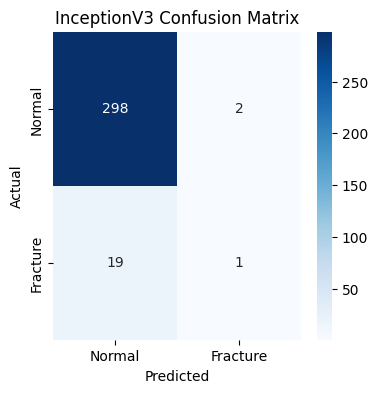

==================== Xception ====================
83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step

Training Xception for 5 epochs...
Epoch 1/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.9197 - loss: 0.2493
Epoch 1: val_accuracy improved from -inf to 0.94044, saving model to /kaggle/working/bone_fracture_work/Xception_best.h5
186/186 ━━━━━━━━━━━━━━━━━━━━ 30s 109ms/step - accuracy: 0.9198 - loss: 0.2491 - val_accuracy: 0.9404 - val_loss: 0.2083 - learning_rate: 0.0010
Epoch 2/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.9415 - loss: 0.1655
Epoch 2: val_accuracy did not improve from 0.94044
186/186 ━━━━━━━━━━━━━━━━━━━━ 14s 76ms/step - accuracy: 0.9415 - loss: 0.1655 - val_accuracy: 0.9404 - val_loss: 0.1782 - learning_rate: 0.0010
Epoch 3/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.9422 - loss: 0.1529
Epoch 3: val_accuracy improved from 0.94044 to 0.95298, saving model to /kaggle/working/bone_fracture_work/Xception_best.h5
186/186 ━━━━━━━━━━━━━━

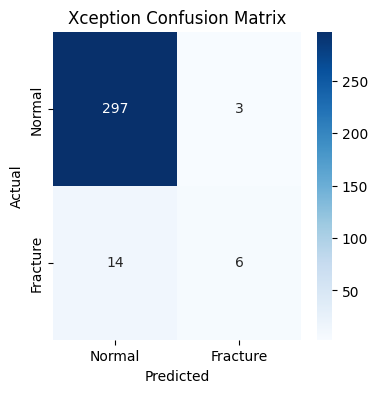

==================== DenseNet121 ====================
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

Training DenseNet121 for 5 epochs...
Epoch 1/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.9177 - loss: 0.2773
Epoch 1: val_accuracy improved from -inf to 0.94044, saving model to /kaggle/working/bone_fracture_work/DenseNet121_best.h5
186/186 ━━━━━━━━━━━━━━━━━━━━ 65s 192ms/step - accuracy: 0.9178 - loss: 0.2771 - val_accuracy: 0.9404 - val_loss: 0.2074 - learning_rate: 0.0010
Epoch 2/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.9356 - loss: 0.2188
Epoch 2: val_accuracy did not improve from 0.94044
186/186 ━━━━━━━━━━━━━━━━━━━━ 14s 74ms/step - accuracy: 0.9356 - loss: 0.2187 - val_accuracy: 0.9404 - val_loss: 0.1874 - learning_rate: 0.0010
Epoch 3/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.9386 - loss: 0.1800
Epoch 3: val_accuracy did not improve from 0.94044
186/186 ━━━━━━━━━━━━━━━━━━━━ 14s 74ms/step - accuracy: 0.9386 - loss: 0.1800 - val_acc

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


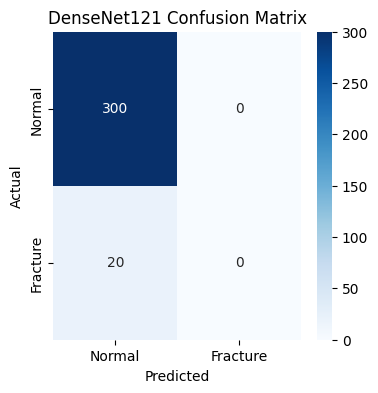

==================== MobileNetV2 ====================


/tmp/ipykernel_38/879226839.py:52: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(include_top=False, weights="imagenet", input_tensor=inputs)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

Training MobileNetV2 for 5 epochs...
Epoch 1/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.9119 - loss: 0.3021
Epoch 1: val_accuracy improved from -inf to 0.94044, saving model to /kaggle/working/bone_fracture_work/MobileNetV2_best.h5
186/186 ━━━━━━━━━━━━━━━━━━━━ 29s 105ms/step - accuracy: 0.9120 - loss: 0.3018 - val_accuracy: 0.9404 - val_loss: 0.2182 - learning_rate: 0.0010
Epoch 2/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.9365 - loss: 0.1972
Epoch 2: val_accuracy did not improve from 0.94044
186/186 ━━━━━━━━━━━━━━━━━━━━ 13s 72ms/step - accuracy: 0.9365 - loss: 0.1971 - val_accuracy: 0.9404 - val_loss: 0.1902 - learning_rate: 0.0010
Epoch 3/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.9466 - loss: 0.1443
Epoch 3: val_accuracy did not improve from 0.94044
186/186 ━━━━━━━━━━━━━━━━━━━━ 14s 73ms/step - accuracy: 0.9466 - loss: 0.1442 - val_accuracy: 0.9404 - val_loss: 0.1761 - learning_rate: 0.0010

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


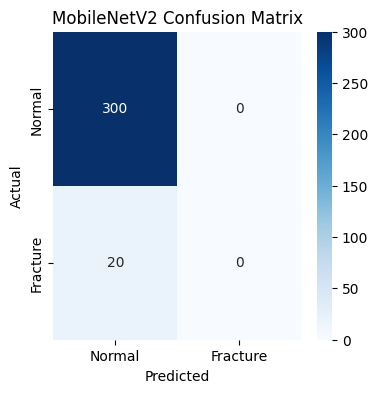

==================== EfficientNetB0 ====================

Training EfficientNetB0 for 5 epochs...
Epoch 1/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.9152 - loss: 0.2944
Epoch 1: val_accuracy improved from -inf to 0.94044, saving model to /kaggle/working/bone_fracture_work/EfficientNetB0_best.h5
186/186 ━━━━━━━━━━━━━━━━━━━━ 45s 125ms/step - accuracy: 0.9153 - loss: 0.2941 - val_accuracy: 0.9404 - val_loss: 0.2261 - learning_rate: 0.0010
Epoch 2/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.9407 - loss: 0.2323
Epoch 2: val_accuracy did not improve from 0.94044
186/186 ━━━━━━━━━━━━━━━━━━━━ 14s 73ms/step - accuracy: 0.9407 - loss: 0.2323 - val_accuracy: 0.9404 - val_loss: 0.2262 - learning_rate: 0.0010
Epoch 3/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.9435 - loss: 0.2210
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 3: val_accuracy did not improve from 0.94044
186/186 ━━━━━━━━━━━━━━━━━━━━ 14s 73ms/step - accura

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


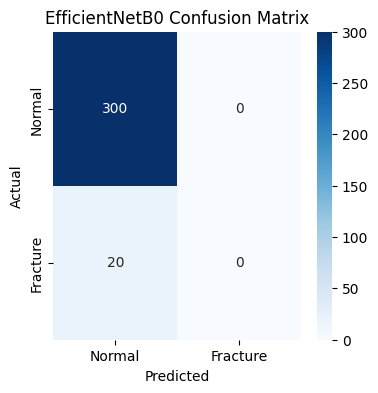

==================== NASNetMobile ====================
19993432/19993432 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

Training NASNetMobile for 5 epochs...
Epoch 1/5
185/186 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.9020 - loss: 0.2814
Epoch 1: val_accuracy improved from -inf to 0.94044, saving model to /kaggle/working/bone_fracture_work/NASNetMobile_best.h5
186/186 ━━━━━━━━━━━━━━━━━━━━ 74s 196ms/step - accuracy: 0.9023 - loss: 0.2808 - val_accuracy: 0.9404 - val_loss: 0.1857 - learning_rate: 0.0010
Epoch 2/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.9433 - loss: 0.1858
Epoch 2: val_accuracy did not improve from 0.94044
186/186 ━━━━━━━━━━━━━━━━━━━━ 14s 74ms/step - accuracy: 0.9433 - loss: 0.1857 - val_accuracy: 0.9404 - val_loss: 0.1699 - learning_rate: 0.0010
Epoch 3/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.9430 - loss: 0.1579
Epoch 3: val_accuracy did not improve from 0.94044
186/186 ━━━━━━━━━━━━━━━━━━━━ 14s 74ms/step - accuracy: 0.9430 - loss: 0.1579 - val_

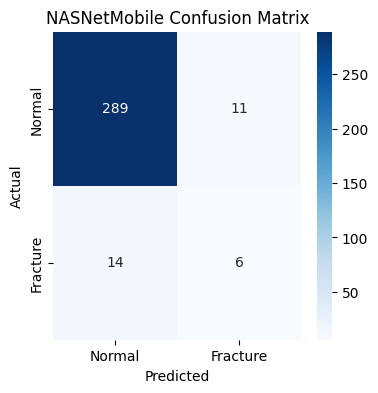


 CNN Leaderboard (Test Split):


,Model,Accuracy,F1-score,Precision,Recall,Specificity
0,Xception,0.946875,0.413793,0.666667,0.30,0.990000
1,ResNet50,0.937500,0.000000,0.000000,0.00,1.000000
2,VGG16,0.937500,0.000000,0.000000,0.00,1.000000
3,DenseNet121,0.937500,0.000000,0.000000,0.00,1.000000
4,EfficientNetB0,0.937500,0.000000,0.000000,0.00,1.000000
5,MobileNetV2,0.937500,0.000000,0.000000,0.00,1.000000
6,InceptionV3,0.934375,0.086957,0.333333,0.05,0.993333
7,NASNetMobile,0.921875,0.324324,0.352941,0.30,0.963333


In [14]:
# ==========================================================
# 8 CNN Backbones Training + Evaluation 
# ==========================================================
import os, gc
import pandas as pd
import tensorflow as tf
from IPython.display import display
from tensorflow.keras.applications import (
    ResNet50, VGG16, InceptionV3, Xception, DenseNet121,
    MobileNetV2, EfficientNetB0, NASNetMobile
)
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


RUN_CNN_MODELS = True
FULL_EPOCHS = 5
DROP = 0.5
L2 = 1e-4
IMG_SIZE = (224, 224)
WORK_DIR = "/kaggle/working/bone_fracture_work"
os.makedirs(WORK_DIR, exist_ok=True)


gpus = tf.config.list_physical_devices('GPU')
if gpus:
    device_name = "/GPU:0"
    print("Using GPU for training:", gpus[0].name)
else:
    device_name = "/CPU:0"
    print(" No GPU found — using CPU.")


def build_keras_backbone(name):
    """Builds and compiles a CNN backbone model."""
    inputs = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

    if name == "ResNet50":
        base = ResNet50(include_top=False, weights="imagenet", input_tensor=inputs)
    elif name == "VGG16":
        base = VGG16(include_top=False, weights="imagenet", input_tensor=inputs)
    elif name == "InceptionV3":
        base = InceptionV3(include_top=False, weights="imagenet", input_tensor=inputs)
    elif name == "Xception":
        base = Xception(include_top=False, weights="imagenet", input_tensor=inputs)
    elif name == "DenseNet121":
        base = DenseNet121(include_top=False, weights="imagenet", input_tensor=inputs)
    elif name == "MobileNetV2":
        base = MobileNetV2(include_top=False, weights="imagenet", input_tensor=inputs)
    elif name == "EfficientNetB0":
        base = EfficientNetB0(include_top=False, weights="imagenet", input_tensor=inputs)
    elif name == "NASNetMobile":
        base = NASNetMobile(include_top=False, weights="imagenet", input_tensor=inputs)
    else:
        raise ValueError(f"Unknown backbone: {name}")

    base.trainable = False
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dropout(DROP)(x)
    out = layers.Dense(1, activation="sigmoid", kernel_regularizer=regularizers.l2(L2))(x)
    m = models.Model(inputs, out, name=f"{name}_bin")
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss="binary_crossentropy", metrics=["accuracy"])
    return m, base


def fit_eval_model(model, name):
    """Trains a CNN and evaluates it using eval_gen."""
    E = FULL_EPOCHS
    ckpt_path = os.path.join(WORK_DIR, f"{name}_best.h5")

    cbs = [
        EarlyStopping(monitor="val_accuracy", patience=3, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1),
        ModelCheckpoint(ckpt_path, monitor="val_accuracy", save_best_only=True, verbose=1),
    ]

    print(f"\nTraining {name} for {E} epochs...")
    with tf.device(device_name):
        history = model.fit(
            train_flow,
            validation_data=val_flow,
            epochs=E,
            callbacks=cbs,
            verbose=1
        )

    print(f"\n Evaluating {name} on test data...")
    with tf.device(device_name):
        result = eval_gen(model, test_flow)

    # Handle dict-style eval_gen
    if isinstance(result, dict):
        res = result
        pred = res["pred"]
        y = res["y"]
        prob = None
    else:
        res, pred, prob, y = result

    print("Classification report:\n", res["report"])

    # Confusion Matrix
    cm = confusion_matrix(y, pred)
    plt.figure(figsize=(4, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Normal", "Fracture"], yticklabels=["Normal", "Fracture"])
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return res, pred, prob, y, history


if RUN_CNN_MODELS:
    cnn_list = [
        "ResNet50", "VGG16", "InceptionV3", "Xception",
        "DenseNet121", "MobileNetV2", "EfficientNetB0", "NASNetMobile"
    ]
    results_cnn = []

    print(" Starting CNN training & evaluation for all backbones...\n")
    for arch in cnn_list:
        print(f"==================== {arch} ====================")
        tf.keras.backend.clear_session()
        gc.collect()

        with tf.device(device_name):
            m2, _ = build_keras_backbone(arch)
            res, pred, prob, y, hist = fit_eval_model(m2, arch)
            results_cnn.append({
                "name": arch,
                "test": res,
                "pred": pred,
                "prob": prob,
                "y": y
            })

        tf.keras.backend.clear_session()
        gc.collect()

    # Leaderboard
    df = pd.DataFrame(
        [[r["name"],
          float(r["test"]["acc"]),
          float(r["test"]["metrics"]["f1"]),
          float(r["test"]["metrics"]["precision"]),
          float(r["test"]["metrics"]["recall"]),
          float(r["test"]["metrics"]["specificity"])]
         for r in results_cnn],
        columns=["Model","Accuracy","F1-score","Precision","Recall","Specificity"]
    ).sort_values("Accuracy", ascending=False)

    print("\n CNN Leaderboard (Test Split):")
    display(df.reset_index(drop=True))
else:
    print("RUN_CNN_MODELS is False — manually force it True if you want to train CNNs.")


## 15. CBAM Attention Module – EfficientNetB0 + CBAM Comparison


CBAM setup → RUN_ATTENTION: True | device: /GPU:0 | classes_ordered: ['fracture', 'normal']

 Training EffB0_PLAIN for 3 epochs…
Epoch 1/3
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.9148 - loss: 0.3013
Epoch 1: val_accuracy improved from -inf to 0.94044, saving model to /kaggle/working/bone_fracture_work/EffB0_PLAIN_best.h5
186/186 ━━━━━━━━━━━━━━━━━━━━ 47s 126ms/step - accuracy: 0.9150 - loss: 0.3010 - val_accuracy: 0.9404 - val_loss: 0.2320 - learning_rate: 0.0010
Epoch 2/3
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.9449 - loss: 0.2178
Epoch 2: val_accuracy did not improve from 0.94044
186/186 ━━━━━━━━━━━━━━━━━━━━ 14s 73ms/step - accuracy: 0.9449 - loss: 0.2179 - val_accuracy: 0.9404 - val_loss: 0.2291 - learning_rate: 0.0010
Epoch 3/3
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.9423 - loss: 0.2230
Epoch 3: val_accuracy did not improve from 0.94044
186/186 ━━━━━━━━━━━━━━━━━━━━ 14s 73ms/step - accuracy: 0.9423 - loss: 0.2230 - val_accuracy: 0.9404 

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


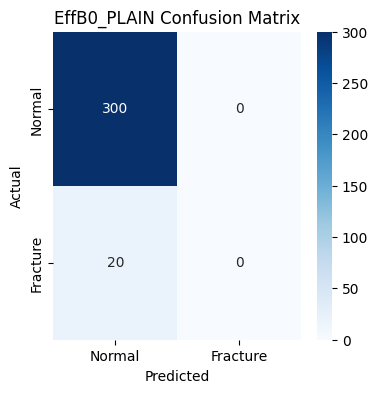


 Training EffB0_CBAM for 3 epochs…
Epoch 1/3
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.9233 - loss: 0.2959
Epoch 1: val_accuracy improved from -inf to 0.94044, saving model to /kaggle/working/bone_fracture_work/EffB0_CBAM_best.h5
186/186 ━━━━━━━━━━━━━━━━━━━━ 50s 132ms/step - accuracy: 0.9234 - loss: 0.2956 - val_accuracy: 0.9404 - val_loss: 0.2262 - learning_rate: 0.0010
Epoch 2/3
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.9483 - loss: 0.2072
Epoch 2: val_accuracy did not improve from 0.94044
186/186 ━━━━━━━━━━━━━━━━━━━━ 13s 72ms/step - accuracy: 0.9482 - loss: 0.2073 - val_accuracy: 0.9404 - val_loss: 0.2273 - learning_rate: 0.0010
Epoch 3/3
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.9353 - loss: 0.2441
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 3: val_accuracy did not improve from 0.94044
186/186 ━━━━━━━━━━━━━━━━━━━━ 14s 73ms/step - accuracy: 0.9353 - loss: 0.2441 - val_accuracy: 0.9404 - val_loss: 0.228

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


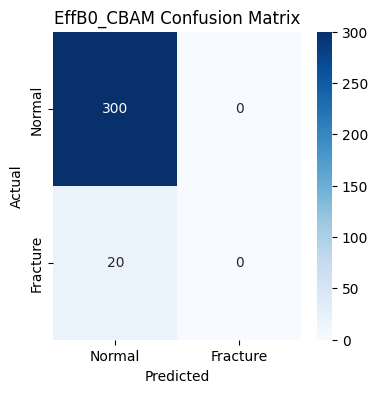


 McNemar: b=0, c=0, p-value=1.000000


In [15]:
# ==========================================================
# enable + train + evaluate + McNemar 
# ==========================================================
import os, gc, numpy as np, tensorflow as tf
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import confusion_matrix
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import backend as K
from statsmodels.stats.contingency_tables import mcnemar


RUN_ATTENTION = True
if "IMG_SIZE" not in globals(): IMG_SIZE = (224, 224)
if "DROP" not in globals(): DROP = 0.5
if "L2" not in globals(): L2 = 1e-4
if "FULL_EPOCHS" not in globals(): FULL_EPOCHS = 5
if "FAST_MODE" not in globals(): FAST_MODE = False
if "WORK_DIR" not in globals(): WORK_DIR = "/kaggle/working/bone_fracture_work"
if "classes_ordered" not in globals(): classes_ordered = ["fracture","normal"]
os.makedirs(WORK_DIR, exist_ok=True)


device_name = "/GPU:0" if tf.config.list_physical_devices('GPU') else "/CPU:0"
print("CBAM setup → RUN_ATTENTION:", RUN_ATTENTION, "| device:", device_name, "| classes_ordered:", classes_ordered)


def cbam_block(inp, r=8, name="cbam"):
    c = K.int_shape(inp)[-1]
    assert c is not None, "CBAM needs known channel dimension"
    c_mid = max(1, c // r)

    gap = layers.GlobalAveragePooling2D(name=f"{name}_gap")(inp)
    gmp = layers.GlobalMaxPooling2D(name=f"{name}_gmp")(inp)
    shared_mlp = tf.keras.Sequential([
        layers.Dense(c_mid, activation="relu", name=f"{name}_fc1"),
        layers.Dense(c, activation=None, name=f"{name}_fc2"),
    ], name=f"{name}_mlp")
    ch = layers.Add(name=f"{name}_ch_add")([shared_mlp(gap), shared_mlp(gmp)])
    ch = layers.Activation("sigmoid", name=f"{name}_ch_sig")(ch)
    ch = layers.Reshape((1,1,c), name=f"{name}_ch_reshape")(ch)
    x = layers.Multiply(name=f"{name}_ch_mul")([inp, ch])

    avg_sp = layers.Lambda(lambda t: tf.reduce_mean(t, axis=-1, keepdims=True), name=f"{name}_sp_avg")(x)
    max_sp = layers.Lambda(lambda t: tf.reduce_max(t, axis=-1, keepdims=True),  name=f"{name}_sp_max")(x)
    sp = layers.Concatenate(axis=-1, name=f"{name}_sp_concat")([avg_sp, max_sp])
    sp = layers.Conv2D(1, (7,7), padding="same", activation="sigmoid", name=f"{name}_sp_conv")(sp)
    out = layers.Multiply(name=f"{name}_sp_mul")([x, sp])
    return out


def build_plain_efficientnet(img_size=IMG_SIZE, drop=DROP, l2=L2, name="EffB0_plain_bin"):
    inp = layers.Input(shape=(img_size[0], img_size[1], 3))
    base = EfficientNetB0(include_top=False, weights="imagenet", input_tensor=inp)
    base.trainable = False
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dropout(drop)(x)
    out = layers.Dense(1, activation="sigmoid", kernel_regularizer=regularizers.l2(l2))(x)
    m = models.Model(inp, out, name=name)
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="binary_crossentropy", metrics=["accuracy"])
    return m

def build_cbam_efficientnet(img_size=IMG_SIZE, drop=DROP, l2=L2, name="EffB0_CBAM_bin"):
    inp = layers.Input(shape=(img_size[0], img_size[1], 3))
    base = EfficientNetB0(include_top=False, weights="imagenet", input_tensor=inp)
    base.trainable = False
    feat = base.output
    x = cbam_block(feat, r=8, name="cbam")
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(drop)(x)
    out = layers.Dense(1, activation="sigmoid", kernel_regularizer=regularizers.l2(l2))(x)
    m = models.Model(inp, out, name=name)
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="binary_crossentropy", metrics=["accuracy"])
    return m


def train_and_eval(model, tag, train_flow, val_flow, test_flow, epochs):
    ckpt = os.path.join(WORK_DIR, f"{tag}_best.h5")
    cbs = [
        EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1),
        ModelCheckpoint(ckpt, monitor="val_accuracy", save_best_only=True, verbose=1),
    ]
    print(f"\n Training {tag} for {epochs} epochs…")
    with tf.device(device_name):
        model.fit(train_flow, validation_data=val_flow, epochs=epochs, callbacks=cbs, verbose=1)

        
        res = eval_gen(model, test_flow)
        if isinstance(res, dict):
            out = res
            y_true, y_pred = out["y"], out["pred"]
        else:
           
            out, y_pred, _, y_true = res

    print(f"\n== {tag} (test) ==")
    print(out["report"])

  
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Normal","Fracture"], yticklabels=["Normal","Fracture"])
    plt.title(f"{tag} Confusion Matrix")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.show()

    return out, y_pred, y_true


if RUN_ATTENTION:
   
    tf.keras.backend.clear_session(); gc.collect()
    m_plain = build_plain_efficientnet()
    res_plain, pred_plain, y_true = train_and_eval(
        m_plain, "EffB0_PLAIN", train_flow, val_flow, test_flow,
        epochs=(FULL_EPOCHS if not FAST_MODE else 3)
    )

    tf.keras.backend.clear_session(); gc.collect()
    m_cbam = build_cbam_efficientnet()
    res_cbam, pred_cbam, y_true2 = train_and_eval(
        m_cbam, "EffB0_CBAM", train_flow, val_flow, test_flow,
        epochs=(FULL_EPOCHS if not FAST_MODE else 3)
    )

  
    assert np.array_equal(y_true, y_true2), "Label mismatch between evaluations."

   
    agree_plain = (pred_plain == y_true)
    agree_cbam  = (pred_cbam  == y_true)
    b = int(np.sum((agree_plain == True)  & (agree_cbam == False)))  # plain correct, cbam wrong
    c = int(np.sum((agree_plain == False) & (agree_cbam == True)))   # cbam correct, plain wrong
    mc = mcnemar([[0, b], [c, 0]], exact=True)
    print(f"\n McNemar: b={b}, c={c}, p-value={mc.pvalue:.6f}")
else:
    print("RUN_ATTENTION is False; set it True to run CBAM.")


## 16. Ensemble Evaluation – Combining Multiple CNN Models


 Using device: /GPU:0
 Searching recursively for models in: /kaggle/working/bone_fracture_work

 Loaded model: /kaggle/working/bone_fracture_work/DenseNet121_best.h5
 Failed to load /kaggle/working/bone_fracture_work/EffB0_CBAM_best.h5: Exception encountered when calling Lambda.call().

We could not automatically infer the shape of the Lambda's output. Please specify the `output_shape` argument for this Lambda layer.

Arguments received by Lambda.call():
  • args=('<KerasTensor shape=(None, 7, 7, 1280), dtype=float32, sparse=False, name=keras_tensor_1696>',)
  • kwargs={'mask': 'None'}
 Loaded model: /kaggle/working/bone_fracture_work/EffB0_PLAIN_best.h5
 Loaded model: /kaggle/working/bone_fracture_work/EfficientNetB0_best.h5
 Loaded model: /kaggle/working/bone_fracture_work/InceptionV3_best.h5
 Loaded model: /kaggle/working/bone_fracture_work/MobileNetV2_best.h5
 Loaded model: /kaggle/working/bone_fracture_work/NASNetMobile_best.h5
 Loaded model: /kaggle/working/bone_fracture_work/Res

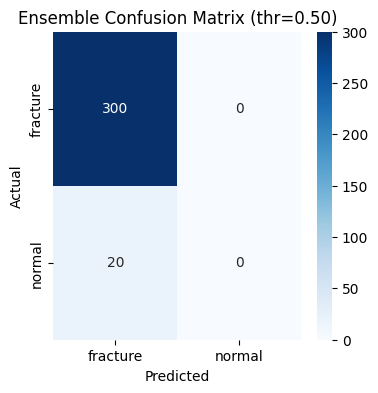

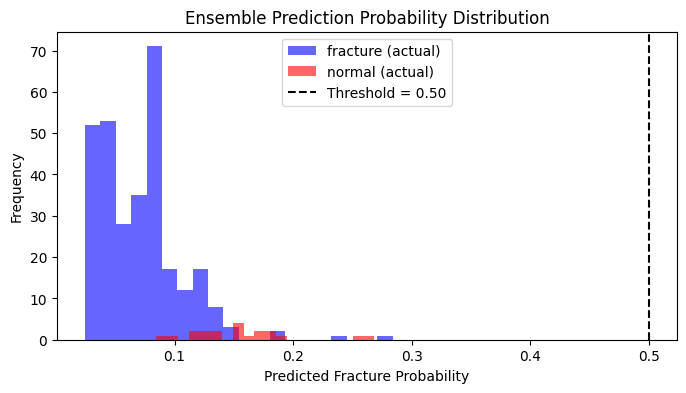

In [16]:

import os, numpy as np, tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns
import matplotlib.pyplot as plt


RUN_ENSEMBLE = True
RUN_CNN_MODELS = True


WORK_DIR = "/kaggle/working/bone_fracture_work"

if "test_flow" not in globals():
    raise RuntimeError("test_flow not defined — please run data loading cell first.")


device_name = "/GPU:0" if tf.config.list_physical_devices('GPU') else "/CPU:0"
print(f" Using device: {device_name}")


def ensemble_predict(models_list, gen):
    """Average soft predictions (probabilities) from multiple Keras models."""
    preds_all = []
    for i, m in enumerate(models_list, 1):
        print(f"Running model {i}/{len(models_list)}: {m.name}")
        with tf.device(device_name):
            p = m.predict(gen, verbose=0).ravel()
        preds_all.append(p)

    preds_all = np.stack(preds_all, axis=0)
    mean_pred = np.mean(preds_all, axis=0)
    return mean_pred


if RUN_ENSEMBLE and RUN_CNN_MODELS:
    top_models = []
    print(f" Searching recursively for models in: {WORK_DIR}\n")

    
    for root, _, files in os.walk(WORK_DIR):
        for f in sorted(files):
            if f.endswith("_best.h5"):
                path = os.path.join(root, f)
                try:
                    with tf.device(device_name):
                        model = tf.keras.models.load_model(path)
                    top_models.append(model)
                    print(f" Loaded model: {path}")
                except Exception as e:
                    print(f" Failed to load {path}: {e}")

    if len(top_models) == 0:
        print(" No saved models found, using current model `m` if available.")
        if "m" in globals():
            top_models = [m]
        else:
            raise RuntimeError(" No models available for ensemble!")

    print(f"\nTotal models used for ensemble: {len(top_models)}")

  
    with tf.device(device_name):
        P = ensemble_predict(top_models, test_flow)

    y_true = np.array(test_flow.classes)
    labels = list(test_flow.class_indices.keys())

   
    best_thr, best_f1 = 0.5, 0
    for t in np.linspace(0.3, 0.7, 21):
        f1 = f1_score(y_true, (P >= t).astype(int))
        if f1 > best_f1:
            best_f1, best_thr = f1, t
    print(f"\n🔹 Optimal threshold for best F1: {best_thr:.2f}")

    yh = (P >= best_thr).astype(int)

    
    print("\n Ensemble Classification Report:")
    print(classification_report(y_true, yh, target_names=labels, digits=4, zero_division=0))

    
    cm = confusion_matrix(y_true, yh)
    plt.figure(figsize=(4, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Ensemble Confusion Matrix (thr={best_thr:.2f})")
    plt.show()

   
    plt.figure(figsize=(8, 4))
    plt.hist(P[y_true == 0], bins=20, alpha=0.6, label=f"{labels[0]} (actual)", color='blue')
    plt.hist(P[y_true == 1], bins=20, alpha=0.6, label=f"{labels[1]} (actual)", color='red')
    plt.axvline(best_thr, color='black', linestyle="--", label=f"Threshold = {best_thr:.2f}")
    plt.title("Ensemble Prediction Probability Distribution")
    plt.xlabel("Predicted Fracture Probability")
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()

else:
    print(" RUN_ENSEMBLE or RUN_CNN_MODELS is False — set both True to run ensemble evaluation.")



## 17. Locate dataset automatically, build Mixt set, visualize ensemble


In [ ]:

import os, random, shutil, cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# 
root_candidates = [
    "/kaggle/input/bone-fracture-dataset/",
    "/kaggle/input/bone-fracture-dataset-only/",
    "/kaggle/input/",
]

SOURCE_TRAIN = None
for root in root_candidates:
    for subdir, dirs, files in os.walk(root):
        if "fracture" in dirs and "normal" in dirs:
            SOURCE_TRAIN = subdir
            break
    if SOURCE_TRAIN:
        break

if not SOURCE_TRAIN:
    raise FileNotFoundError(" Could not find dataset folders containing 'fracture' and 'normal'!")

print(f" Detected training folder: {SOURCE_TRAIN}")


MIXT_DIR = "/kaggle/working/mixt_flat"
WORK_DIR = "/kaggle/working/bone_fracture_work"
IMG_SIZE = (224, 224)
NUM_SAMPLES_PER_CLASS = 10  


if os.path.exists(MIXT_DIR):
    shutil.rmtree(MIXT_DIR)
os.makedirs(MIXT_DIR, exist_ok=True)

def copy_random_images(class_name, n=10):
    src_class_path = os.path.join(SOURCE_TRAIN, class_name)
    if not os.path.exists(src_class_path):
        raise FileNotFoundError(f" Folder not found: {src_class_path}")
    images = [f for f in os.listdir(src_class_path) if f.lower().endswith(('jpg', 'jpeg', 'png'))]
    if len(images) == 0:
        raise ValueError(f" No images found in {src_class_path}")
    selected = random.sample(images, min(n, len(images)))
    for img in selected:
        shutil.copy2(os.path.join(src_class_path, img), os.path.join(MIXT_DIR, f"{class_name}_{img}"))

copy_random_images("fracture", NUM_SAMPLES_PER_CLASS)
copy_random_images("normal", NUM_SAMPLES_PER_CLASS)
print(f" Mixt test set created with {len(os.listdir(MIXT_DIR))} images at {MIXT_DIR}")


device_name = "/GPU:0" if tf.config.list_physical_devices('GPU') else "/CPU:0"
print(f" Using device: {device_name}")

models_list = []
for f in sorted(os.listdir(WORK_DIR)):
    if f.endswith("_best.h5"):
        model_path = os.path.join(WORK_DIR, f)
        try:
            with tf.device(device_name):
                model = tf.keras.models.load_model(model_path)
            models_list.append(model)
            print(f" Loaded: {f}")
        except Exception as e:
            print(f"Failed to load {f}: {e}")

if len(models_list) == 0:
    raise RuntimeError(" No trained models found in bone_fracture_work!")


def ensemble_predict_image(img_path):
    """Predicts average probability of 'fracture' using ensemble of models."""
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE)
    arr = np.expand_dims(img.astype("float32") / 255.0, axis=0)

    preds = []
    for m in models_list:
        with tf.device(device_name):
            p = m.predict(arr, verbose=0)[0][0]
        preds.append(p)
    mean_prob = np.mean(preds)
    return mean_prob, img


images = [os.path.join(MIXT_DIR, f) for f in os.listdir(MIXT_DIR)
          if f.lower().endswith(('jpg', 'jpeg', 'png'))]
random.shuffle(images)

plt.figure(figsize=(18, 9))
for i, img_path in enumerate(images[:NUM_SAMPLES_PER_CLASS * 2]):
    prob, img = ensemble_predict_image(img_path)
    pred = "Fracture" if prob >= 0.5 else "Normal"
    actual = "Fracture" if "fracture" in img_path.lower() else "Normal"
    color = "green" if pred == actual else "red"

    plt.subplot(2, NUM_SAMPLES_PER_CLASS, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Actual: {actual}\nPred: {pred}\nConf: {prob:.2f}", color=color, fontsize=10)

plt.suptitle(" Ensemble Visual Check (Flat Mixt Folder)", fontsize=16)
plt.tight_layout()
plt.show()


 Detected training folder: /kaggle/input/bone-fracture-dataset/Bone fracture dataset/Dataset
 Mixt test set created with 20 images at /kaggle/working/mixt_flat
 Using device: /GPU:0
 Loaded: DenseNet121_best.h5
Failed to load EffB0_CBAM_best.h5: Exception encountered when calling Lambda.call().

We could not automatically infer the shape of the Lambda's output. Please specify the `output_shape` argument for this Lambda layer.

Arguments received by Lambda.call():
  • args=('<KerasTensor shape=(None, 7, 7, 1280), dtype=float32, sparse=False, name=keras_tensor_7517>',)
  • kwargs={'mask': 'None'}
 Loaded: EffB0_PLAIN_best.h5
 Loaded: EfficientNetB0_best.h5
 Loaded: InceptionV3_best.h5
 Loaded: MobileNetV2_best.h5
 Loaded: NASNetMobile_best.h5
 Loaded: ResNet50_best.h5
 Loaded: VGG16_best.h5
 Loaded: Xception_best.h5



## 18. 5-Fold Cross-Validation 


In [18]:

import os, shutil, glob, gc
import numpy as np
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf


RUN_FIVE_FOLD = True
FULL_EPOCHS = 5
DROP = 0.5
L2 = 1e-4
IMG_SIZE = (224, 224)


if tf.config.list_physical_devices('GPU'):
    device_name = "/GPU:0"
    print("Using GPU for K-Fold training.")
else:
    device_name = "/CPU:0"
    print(" No GPU found — using CPU for K-Fold training.")


def build_efficientnet(img_size=IMG_SIZE, drop=DROP, l2=L2):
    """Reusable EfficientNetB0 binary classifier."""
    from tensorflow.keras import layers, models, regularizers
    from tensorflow.keras.applications import EfficientNetB0
    inp = layers.Input(shape=(img_size[0], img_size[1], 3))
    base = EfficientNetB0(include_top=False, weights="imagenet", input_tensor=inp)
    base.trainable = False
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dropout(drop)(x)
    out = layers.Dense(1, activation="sigmoid", kernel_regularizer=regularizers.l2(l2))(x)
    m = models.Model(inp, out, name="EffNetB0_CV")
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss="binary_crossentropy", metrics=["accuracy"])
    return m, base


def run_kfold(arch="EfficientNetB0", k=5):
    """Performs K-fold cross-validation with stratified splits."""
    files, labels = [], []
    for c in classes:
        for p in glob.glob(os.path.join(TRAIN_DIR, c, "*")):
            files.append(p)
            labels.append(c)
    files, labels = np.array(files), np.array(labels)
    y_enc = (labels == classes[1]).astype(int)

    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    scores = []

    for fold, (tr, va) in enumerate(skf.split(files, y_enc), 1):
        print(f"\n========== Fold {fold}/{k} ==========")
        tmp_tr = os.path.join(WORK_DIR, f"cv_tr_{fold}")
        tmp_va = os.path.join(WORK_DIR, f"cv_va_{fold}")

    
        for pth in [tmp_tr, tmp_va]:
            if os.path.exists(pth):
                shutil.rmtree(pth)
            for c in classes:
                os.makedirs(os.path.join(pth, c), exist_ok=True)

       
        for i in tr:
            shutil.copy2(files[i], os.path.join(tmp_tr, labels[i], os.path.basename(files[i])))
        for i in va:
            shutil.copy2(files[i], os.path.join(tmp_va, labels[i], os.path.basename(files[i])))

        
        train_gen = ImageDataGenerator(preprocessing_function=preprocessing_function).flow_from_directory(
            tmp_tr, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="binary")
        val_gen = ImageDataGenerator(preprocessing_function=preprocessing_function).flow_from_directory(
            tmp_va, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="binary", shuffle=False)

       
        with tf.device(device_name):
            model, _ = build_efficientnet()
            cb = [EarlyStopping(monitor="val_accuracy", patience=3, restore_best_weights=True, verbose=1)]
            model.fit(train_gen, validation_data=val_gen,
                      epochs=FULL_EPOCHS, callbacks=cb, verbose=1)

           
            _, acc = model.evaluate(val_gen, verbose=0)
            print(f"Fold {fold} accuracy: {acc:.4f}")
            scores.append(acc)

        
        shutil.rmtree(tmp_tr, ignore_errors=True)
        shutil.rmtree(tmp_va, ignore_errors=True)
        tf.keras.backend.clear_session()
        gc.collect()

    print("\nCross-validation results:")
    print("Accuracies:", [round(s, 4) for s in scores])
    print("Mean accuracy:", round(float(np.mean(scores)), 4))
    return scores


if RUN_FIVE_FOLD:
    cv_scores = run_kfold("EfficientNetB0", k=5)
else:
    print("RUN_FIVE_FOLD is False — skipping cross-validation.")


Using GPU for K-Fold training.

========== Fold 1/5 ==========
Found 1190 images belonging to 2 classes.
Found 298 images belonging to 2 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 54s 404ms/step - accuracy: 0.8981 - loss: 0.3291 - val_accuracy: 0.9396 - val_loss: 0.2283
Epoch 2/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 11s 146ms/step - accuracy: 0.9384 - loss: 0.2336 - val_accuracy: 0.9396 - val_loss: 0.2290
Epoch 3/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 11s 145ms/step - accuracy: 0.9484 - loss: 0.2053 - val_accuracy: 0.9396 - val_loss: 0.2283
Epoch 4/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 12s 161ms/step - accuracy: 0.9496 - loss: 0.2091 - val_accuracy: 0.9396 - val_loss: 0.2283
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.
Fold 1 accuracy: 0.9396

========== Fold 2/5 ==========
Found 1190 images belonging to 2 classes.
Found 298 images belonging to 2 classes.
Epoch 1/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 49s 377ms/step - accuracy: 0.9237 - loss: 0.3042 - val_accuracy: 0.9396 - val_loss: 0.2285
Epoch 2/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 11s 145ms/step - accuracy: 0.9407 - loss: 0.2274 - val_accuracy: 0.9396 - val_loss: 0.2283
Epoch 3/5
